## 1. Import lib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import sparse
from scipy.sparse import hstack
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.feature_selection import chi2, f_classif, SelectFpr, SelectKBest
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
# from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## 2. Load dataset

In [3]:
df = pd.read_csv('/content/drive/Shareddrives/Học máy trong kinh doanh/Data/DataCoSupplyChainDataset.csv',encoding='latin-1')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Feature selection

### Chi_square

Dùng chi_squared đề chọn feature khi có X (ma trận các biến category và y là phân loại)
- (kể cả biến feature trong X có nhiều giá trị (miễn là phải phân loại)
- pvalue > 0.5: ko lấy, bé hơn thì lấy
- chú ý ko sử dụng để lựa chọn khi X có các biến ordinal (thức bậc), continous (biến liên tục)
- Link: https://www.hackersrealm.net/post/feature-selection-using-chi-square

In [19]:
X = df[categorical_features]
y = df['Late_delivery_risk']

In [20]:
X.columns

Index(['Type', 'Category Name', 'Customer Segment', 'Market', 'Order City',
       'Order Country', 'Order State', 'Order Region', 'Order Status',
       'Product Status', 'Shipping Mode', 'Department Name', 'Customer City',
       'Customer Country', 'Customer State', 'Delivery Status'],
      dtype='object')

In [21]:
for col in X.columns:
    X[col] = LabelEncoder().fit_transform(X[col])

/tmp/ipykernel_871/121888855.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipykernel_871/121888855.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipykernel_871/121888855.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [22]:
chi_scores = chi2(X, y)

<Axes: >

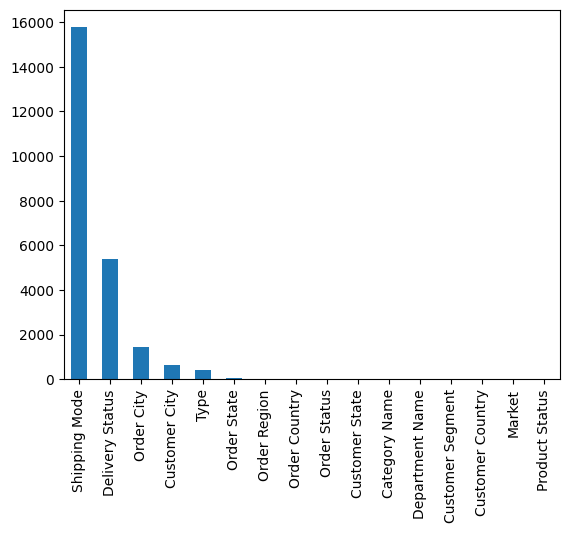

In [23]:
chi_values = pd.Series(chi_scores[0], index=X.columns)
chi_values.sort_values(ascending=False, inplace=True)
chi_values.plot.bar()

<Axes: >

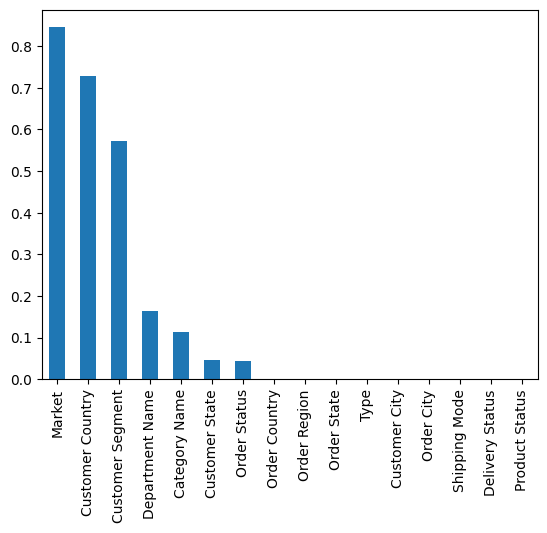

In [24]:
# if p-value > 0.05, lower the importance
p_values = pd.Series(chi_scores[1], index=X.columns)
p_values.sort_values(ascending=False, inplace=True)
p_values.plot.bar()

Với p-value < 0.05:
- Giữ lại các biến: ['Department Name', 'Category Name', 'Customer State',   'Order Status', 'Order Country', 'Order Region', 'Order State', 'Type', 'Customer City', 'Order City',
  'Shipping Mode', 'Product Status', 'Delivery Status']

<Axes: xlabel='Product Status', ylabel='count'>

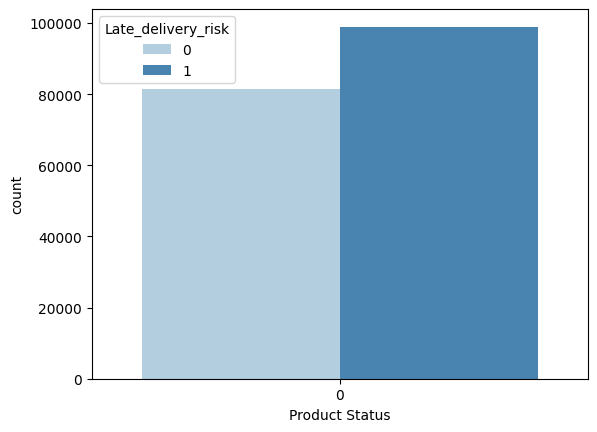

In [ ]:
sns.countplot(df, x = 'Product Status', hue = 'Late_delivery_risk', palette = 'Blues')

Product Status chỉ có 1 trạng thái --> Dễ khiến mô hình học 'thiên vị' --> Loại bỏ

/tmp/ipython-input-2466332986.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
/tmp/ipython-input-2466332986.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cramer_df, x="Cramer's V", y="Variable", palette="viridis")


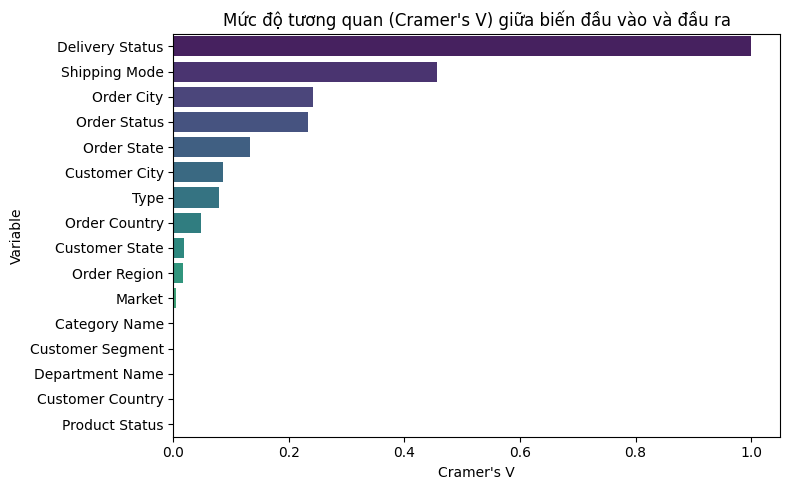

In [ ]:
# Hàm tính Cramer's V
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


output_var = 'Late_delivery_risk'

# Tính Cramer's V cho từng biến
results = []
for col in categorical_features:
    val = cramers_v(df[col], df[output_var])
    results.append((col, val))

# Chuyển sang DataFrame
cramer_df = pd.DataFrame(results, columns=['Variable', "Cramer's V"])
cramer_df = cramer_df.sort_values("Cramer's V", ascending=False)

# Vẽ barplot
plt.figure(figsize=(8,5))
sns.barplot(data=cramer_df, x="Cramer's V", y="Variable", palette="viridis")
plt.title("Mức độ tương quan (Cramer's V) giữa biến đầu vào và đầu ra")
plt.tight_layout()
plt.show()


Biến Delivery Status có tương quan gần bằng 1 với biến đầu ra --> Dễ bị overfit --> Loại bỏ
- Giữ lại các biến categorical quan trọng:
['Department Name', 'Category Name', 'Customer State',
                                 'Order Status', 'Order Country', 'Order Region',
                                 'Order State', 'Type', 'Customer City', 'Order City',
                                 'Shipping Mode']


### Heatmap

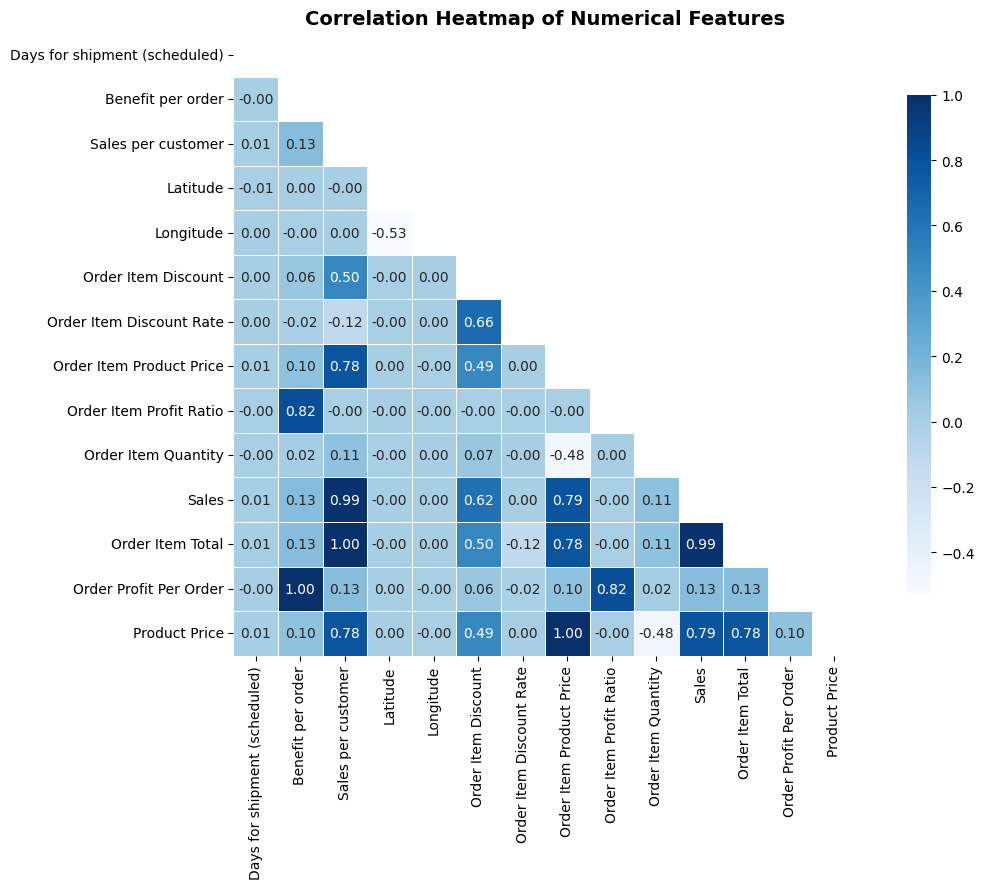

In [ ]:
# Tính ma trận tương quan
corr_matrix = df[numeric_cols ].corr()

# Mask tam giác trên
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Data Preprocessing

### New data

In [ ]:
selected_categorical_features_trong = ['Department Name', 'Category Name', 'Customer State',
                                 'Order Status', 'Order Country', 'Order Region',
                                 'Order State', 'Type', 'Customer City', 'Order City',
                                 'Shipping Mode']
selected_numerical_features_trong = ['Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer',
       'Latitude', 'Longitude', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity']

# Gộp tất cả lại thành list cột cuối cùng
selected_features = selected_categorical_features_trong + selected_numerical_features_trong + ['Late_delivery_risk']

# Lọc DataFrame
df_selected = df[selected_features].copy()
df_selected.head()

,Department Name,Category Name,Customer State,Order Status,Order Country,Order Region,Order State,Type,Customer City,Order City,...,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Late_delivery_risk
0,Fitness,Sporting Goods,PR,COMPLETE,Indonesia,Southeast Asia,Java Occidental,DEBIT,Caguas,Bekasi,...,4,91.250000,314.640015,18.251453,-66.037056,0.04,327.75,0.29,1,0
1,Fitness,Sporting Goods,PR,PENDING,India,South Asia,Rajastán,TRANSFER,Caguas,Bikaner,...,4,-249.089996,311.359985,18.279451,-66.037064,0.05,327.75,-0.80,1,1
2,Fitness,Sporting Goods,CA,CLOSED,India,South Asia,Rajastán,CASH,San Jose,Bikaner,...,4,-247.779999,309.720001,37.292233,-121.881279,0.06,327.75,-0.80,1,0
3,Fitness,Sporting Goods,CA,COMPLETE,Australia,Oceania,Queensland,DEBIT,Los Angeles,Townsville,...,4,22.860001,304.809998,34.125946,-118.291016,0.07,327.75,0.08,1,0
4,Fitness,Sporting Goods,PR,PENDING_PAYMENT,Australia,Oceania,Queensland,PAYMENT,Caguas,Townsville,...,4,134.210007,298.250000,18.253769,-66.037048,0.09,327.75,0.45,1,0


### Missing value

In [ ]:
missing_value = (df.isnull().sum() / len(df)) * 100
print(missing_value[missing_value > 0])

Customer Lname           0.004432
Customer Zipcode         0.001662
Order Zipcode           86.239676
Product Description    100.000000
dtype: float64


Không có missing value --> Không xử lý

### Outlier

In [ ]:
df_filtered = df_clean.copy()

In [ ]:
cols_to_check_outlier = numeric_cols # list
for col in cols_to_check_outlier:
    if col in df_filtered.columns and pd.api.types.is_numeric_dtype(df_filtered[col]):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 5 * IQR
        upper_bound = Q3 + 5 * IQR

        df_filtered = df_filtered[(df_filtered[col] > lower_bound) & (df_filtered[col] < upper_bound)]
print('Số dòng ban đầu: ', df.shape[0])
print('Số dòng còn lại: ', df_filtered.shape[0])
print('Số dòng bị loại bỏ bởi outlier: ', df.shape[0] - df_filtered.shape[0])

Số dòng ban đầu:  180519
Số dòng còn lại:  173553
Số dòng bị loại bỏ bởi outlier:  6966


### Drop irrelevant value

In [ ]:
# Giữ lại các dòng không phải CANCELED hoặc SUSPECTED_FRAUD
df_selected = df_selected[~df_selected['Order Status'].isin(['CANCELED', 'SUSPECTED_FRAUD'])]
df_selected

,Department Name,Category Name,Customer State,Order Status,Order Country,Order Region,Order State,Type,Customer City,Order City,...,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Late_delivery_risk
0,Fitness,Sporting Goods,PR,COMPLETE,Indonesia,Southeast Asia,Java Occidental,DEBIT,Caguas,Bekasi,...,4,91.250000,314.640015,18.251453,-66.037056,0.04,327.750000,0.29,1,0
1,Fitness,Sporting Goods,PR,PENDING,India,South Asia,Rajastán,TRANSFER,Caguas,Bikaner,...,4,-249.089996,311.359985,18.279451,-66.037064,0.05,327.750000,-0.80,1,1
2,Fitness,Sporting Goods,CA,CLOSED,India,South Asia,Rajastán,CASH,San Jose,Bikaner,...,4,-247.779999,309.720001,37.292233,-121.881279,0.06,327.750000,-0.80,1,0
3,Fitness,Sporting Goods,CA,COMPLETE,Australia,Oceania,Queensland,DEBIT,Los Angeles,Townsville,...,4,22.860001,304.809998,34.125946,-118.291016,0.07,327.750000,0.08,1,0
4,Fitness,Sporting Goods,PR,PENDING_PAYMENT,Australia,Oceania,Queensland,PAYMENT,Caguas,Townsville,...,4,134.210007,298.250000,18.253769,-66.037048,0.09,327.750000,0.45,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Fan Shop,Fishing,NY,CLOSED,China,Eastern Asia,Shanghái,CASH,Brooklyn,Shanghái,...,4,40.000000,399.980011,40.640930,-73.942711,0.00,399.980011,0.10,1,0
180515,Fan Shop,Fishing,CA,COMPLETE,Japón,Eastern Asia,Osaka,DEBIT,Bakersfield,Hirakata,...,2,-613.770019,395.980011,35.362545,-119.018700,0.01,399.980011,-1.55,1,1
180516,Fan Shop,Fishing,CT,PENDING,Australia,Oceania,Australia del Sur,TRANSFER,Bristol,Adelaide,...,4,141.110001,391.980011,41.629959,-72.967155,0.02,399.980011,0.36,1,1
180517,Fan Shop,Fishing,PR,PENDING_PAYMENT,Australia,Oceania,Australia del Sur,PAYMENT,Caguas,Adelaide,...,4,186.229996,387.980011,18.213350,-66.370575,0.03,399.980011,0.48,1,0


In [ ]:
df_selected.to_csv('/content/drive/MyDrive/data/data.csv', index=False)  # Lưu vào Google Drive

In [ ]:
selected_trong = selected_categorical_features_trong + selected_numerical_features_trong

### StandardScaler

In [ ]:
encoded_cols = pd.get_dummies(df['Shipping Mode'], prefix='ShipMode').astype(int)
display_rows = df.groupby('Shipping Mode').head(1).index
encoded_cols.loc[display_rows]



,ShipMode_First Class,ShipMode_Same Day,ShipMode_Second Class,ShipMode_Standard Class
0,0,0,0,1
6,1,0,0,0
8,0,0,1,0
19,0,1,0,0


In [ ]:
cat_cols = [
   'Department Name', 'Category Name', 'Customer State', 'Order Status', 'Order Country', 'Order Region', 'Order State', 'Type', 'Customer City', 'Order City', 'Shipping Mode'
]


In [ ]:
unique_counts = df[cat_cols].nunique().sort_values(ascending=False)
print(unique_counts)


Order City         3597
Order State        1089
Customer City       563
Order Country       164
Category Name        50
Customer State       46
Order Region         23
Department Name      11
Order Status          9
Type                  4
Shipping Mode         4
dtype: int64


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Giả sử bạn đã có các biến định lượng được chọn
selected_numerical_features_trong = [
    'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer',
    'Latitude', 'Longitude', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio',
    'Order Item Quantity'
]

# Fit và transform StandardScaler trên tập train
scaler = StandardScaler()
X_train_num = df[selected_numerical_features_trong]
X_train_scaled = scaler.fit_transform(X_train_num)

# Tạo DataFrame để so sánh
comparison_df = pd.DataFrame({
    'Feature': selected_numerical_features_trong,
    'Before Scaling (mean)': [X_train_num[col].mean() for col in selected_numerical_features_trong],
    'After Scaling (mean)': [X_train_scaled[:, i].mean() for i in range(len(selected_numerical_features_trong))]
})

# Hiển thị 3 cột: tên biến, giá trị trung bình trước và sau khi chuẩn hóa
print(comparison_df)


                         Feature  Before Scaling (mean)  After Scaling (mean)
0  Days for shipment (scheduled)               2.931847          1.429202e-16
1              Benefit per order              21.974989         -3.930206e-17
2             Sales per customer             183.107609         -3.816453e-16
3                       Latitude              29.719955          2.499233e-16
4                      Longitude             -84.915675          3.321585e-16
5       Order Item Discount Rate               0.101668          1.523275e-16
6       Order Item Product Price             141.232550         -1.612231e-16
7        Order Item Profit Ratio               0.120647          2.916658e-17
8            Order Item Quantity               2.127638          1.916099e-16


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Các biến định lượng được chọn
selected_numerical_features_trong = [
    'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer',
    'Latitude', 'Longitude', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio',
    'Order Item Quantity'
]

# Lấy dữ liệu gốc
X_train_num = df[selected_numerical_features_trong]

# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)

# Tạo DataFrame so sánh
comparison_df = pd.DataFrame({
    'Feature': selected_numerical_features_trong,
    'Mean (Before Scaling)': [X_train_num[col].mean() for col in selected_numerical_features_trong],
    'Std (Before Scaling)': [X_train_num[col].std() for col in selected_numerical_features_trong],
    'Mean (After Scaling)': [X_train_scaled[:, i].mean() for i in range(len(selected_numerical_features_trong))],
    'Std (After Scaling)': [X_train_scaled[:, i].std() for i in range(len(selected_numerical_features_trong))]
})

# Làm đẹp bảng hiển thị
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
comparison_df

,Feature,Mean (Before Scaling),Std (Before Scaling),Mean (After Scaling),Std (After Scaling)
0,Days for shipment (scheduled),2.9318,1.3744,0.0000,1.0000
1,Benefit per order,21.9750,104.4335,-0.0000,1.0000
2,Sales per customer,183.1076,120.0437,-0.0000,1.0000
3,Latitude,29.7200,9.8136,0.0000,1.0000
4,Longitude,-84.9157,21.4332,0.0000,1.0000
5,Order Item Discount Rate,0.1017,0.0704,0.0000,1.0000
6,Order Item Product Price,141.2325,139.7325,-0.0000,1.0000
7,Order Item Profit Ratio,0.1206,0.4668,0.0000,1.0000
8,Order Item Quantity,2.1276,1.4535,0.0000,1.0000


In [ ]:
selected_categorical_features_trong = ['Department Name', 'Category Name', 'Customer State',
                                 'Order Status', 'Order Country', 'Order Region',
                                 'Order State', 'Type', 'Customer City', 'Order City',
                                 'Shipping Mode']
selected_numerical_features_trong = ['Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer',
       'Latitude', 'Longitude', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity']
selected_trong = selected_categorical_features_trong + selected_numerical_features_trong

In [ ]:
X = df_selected[selected_trong]
y = df_selected['Late_delivery_risk']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = True)
encoder.fit(X_train[selected_categorical_features_trong])

X_train_cate = encoder.transform(X_train[selected_categorical_features_trong])
X_test_cate = encoder.transform(X_test[selected_categorical_features_trong])

X_train_num = sparse.csr_matrix(X_train[selected_numerical_features_trong].values)
X_test_num = sparse.csr_matrix(X_test[selected_numerical_features_trong].values)

X_train_all = hstack((X_train_num, X_train_cate))
X_test_all = hstack((X_test_num, X_test_cate))

scaler = StandardScaler(with_mean = False)
X_train_final = scaler.fit_transform(X_train_all)
X_test_final = scaler.transform(X_test_all)